# UMAP + HDBSCAN for RBD Downsampled(Alpha, Delta, Omicron)

Embedded using ESM2 8M model, script for embedding from `clustering/rbd` notebooks. Finetuned (NOT base model).

In [65]:
version_dir = "rbd_ado_finetuned"
version_prefix = "RBD.ADO.from-esm-mlm_CLS-embedded"

In [ ]:
import os
import pandas as pd

data_dir = "/panfs/biopan03/prime_ml/prime/data/rbd/old"
parquet_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/blackwell/rbd/parquets"

parquet_file = os.path.join(data_dir, "spikeprot0528.clean.uniq.noX.RBD.metadata.variants.ADO.from-esm-mlm_CLS-embedded.parquet")
embedded_ado_df = pd.read_parquet(parquet_file, engine='fastparquet')

# Random sampling
min_sample_size = embedded_ado_df['variant'].value_counts().min()
sample_sizes = {"Alpha": min_sample_size,
                "Delta": min_sample_size,
                "Omicron": min_sample_size}

random_seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8]
for rnd_seed in random_seeds:
    seeded_sampled_dfs = [embedded_ado_df[embedded_ado_df['variant'] == variant].sample(n=sample_sizes[variant], random_state=rnd_seed)
                            for variant in sample_sizes.keys()]
        
    seeded_sampled_ado_df = pd.concat(seeded_sampled_dfs)
    save_as = f"{version_prefix}.sampled_seed{rnd_seed}.parquet"
    seeded_sampled_ado_df.to_parquet(os.path.join(parquet_dir, version_dir, save_as), index=False)

In [467]:
rnd_seed = 0
sampled_ado_df = pd.read_parquet(os.path.join(parquet_dir, version_dir, f"{version_prefix}.sampled_seed{rnd_seed}.parquet"), engine="fastparquet")

print(sampled_ado_df['variant'].value_counts())
display(sampled_ado_df)

variant
Alpha      22075
Delta      22075
Omicron    22075
Name: count, dtype: int64


,seq_id,variant,Pango lineage,Location,Collection date,AA Substitutions,embedding
0,EPI_ISL_2532772,Alpha,B.1.1.7,Europe / Czech Republic,2021-02-03,"(Spike_H69del,NS8_Q27stop,NSP3_T183I,Spike_T71...","[-0.11811064, 0.42240408, 0.5593408, 0.6619772..."
1,EPI_ISL_4381354,Alpha,B.1.1.7,North America / USA / Michigan,2021-04-30,"(Spike_H69del,NS8_Q27stop,NSP3_T183I,NS3_K16de...","[-0.11811064, 0.42240408, 0.5593408, 0.6619772..."
2,EPI_ISL_920856,Alpha,B.1.1.7,Europe / United Kingdom / England,2021-01-05,"(Spike_H69del,NS8_Q27stop,NSP3_T183I,Spike_T71...","[-0.11811064, 0.42240408, 0.5593408, 0.6619772..."
3,EPI_ISL_2765113,Alpha,B.1.1.7,Asia / Japan / Kyoto,2021-05-04,"(Spike_H69del,NS8_Q27stop,NSP3_T183I,Spike_T71...","[-0.11811064, 0.42240408, 0.5593408, 0.6619772..."
4,EPI_ISL_1191671,Alpha,B.1.1.7,Europe / France / Auvergne-Rhone-Alpes / Lyon,2021-02-05,"(Spike_S94F,Spike_H69del,NS8_Q27stop,NSP3_T183...","[-0.11811064, 0.42240408, 0.5593408, 0.6619772..."
...,...,...,...,...,...,...,...
66220,EPI_ISL_15491233,Omicron,BA.2,South America / Brazil / Mato Grosso do Sul / ...,2022-03-21,"(NSP5_P132H,NSP3_G489S,Spike_L24del,NSP4_T327I...","[-0.07654145, 0.3855804, 0.36136034, 0.6001248..."
66221,EPI_ISL_16083777,Omicron,BF.7,North America / USA / Texas,2022-11-25,"(NSP5_P132H,Spike_H69del,NSP3_G489S,Spike_L24d...","[-0.054073647, 0.50378656, 0.5165999, 0.555720..."
66222,EPI_ISL_14780424,Omicron,BA.5.1,Asia / Cambodia,2022-08-18,"(NSP5_P132H,Spike_H69del,NSP3_G489S,Spike_L24d...","[-0.031108553, 0.3616447, 0.36917767, 0.598314..."
66223,EPI_ISL_16580822,Omicron,BN.1.4,Asia / Japan / Chiba,2022-12-29,"(NSP5_P132H,NSP12_G671S,NSP3_G489S,Spike_L24de...","[-0.23086427, 0.5753332, 0.7663285, 0.60162747..."


---
## UMAP Parameter Sweep
(doc: https://docs.rapids.ai/api/cuml/stable/api/generated/cuml.manifold.umap/#cuml.manifold.UMAP)

Some more on parameters for UMAP:
- https://umap-learn.readthedocs.io/en/latest/parameters.html
- https://pair-code.github.io/understanding-umap/

We adjust our parameter sweep to include noise fraction. This is the proportion of points that HDBSCAN labels as noise/outliers, meaning they are not assigned to any cluster.

For example: If you have 100 sequences and HDBSCAN labels:
- 80 into clusters
- 20 as -1
- Then: noise_fraction = 20 / 100 = 0.20. This results in a noise_fraction of 0.2, or 20% of the data!

Why does it matter?
| Noise fraction | Interpretation                                  |
| -------------- | ----------------------------------------------- |
| Low            | most points were assigned to clusters           |
| Moderate       | HDBSCAN is being selective                      |
| High           | many points do not fit well into dense clusters |

This will allow us to better make sense of our ARI scores. Some scenarios to help make better sense:
| ARI  | Noise fraction | Interpretation                             |
| ---- | -------------- | ------------------------------------------ |
| High | Low            | Strong result                              |
| High | Very high      | Maybe only a subset clustered well         |
| Low  | High           | Clustering may be too strict               |
| Low  | Low            | Clustering may be forcing poor assignments |

And a more specific example:
| Setting | ARI  | Noise fraction |
| ------- | ---- | -------------- |
| A       | 0.82 | 0.08           |
| B       | 0.83 | 0.47           |

I would usually trust A more, because B is discarding almost half the dataset.

In [ ]:
import os
from sklearn.model_selection import ParameterGrid
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

import cupy as cp
from cuml.manifold import UMAP
from cuml.cluster import HDBSCAN
from cuml.preprocessing import LabelEncoder
from cuml.metrics.cluster import adjusted_rand_score, silhouette_score

def umap_hdbscan_parameter_sweep(parquet_file, embedded_df, n_neighbors_list, min_dist_list, min_samples_list, min_cluster_size_list):
    umap_grid = {
        "n_neighbors": n_neighbors_list,
        "min_dist": min_dist_list,
    }
    umap_param_list = list(ParameterGrid(umap_grid))

    hdbscan_grid = {
        "min_samples": min_samples_list,
        "min_cluster_size": min_cluster_size_list,
    }
    hdbscan_param_list = list(ParameterGrid(hdbscan_grid))

    all_results = []

    # CPU -> GPU
    embedding_matrix = np.vstack(embedded_df["embedding"].values).astype(np.float32)
    X_gpu = cp.asarray(embedding_matrix)
    y_true = LabelEncoder().fit_transform(embedded_df["variant"].values)
    y_true_gpu = cp.asarray(y_true)

    # Parameter Sweep (UMAP)
    for umap_params in tqdm(umap_param_list, desc="UMAP sweep"):
        reducer = UMAP(
            n_neighbors=umap_params["n_neighbors"],
            min_dist=umap_params["min_dist"],
            metric="cosine",
            random_state=42,
        )
        X_red = reducer.fit_transform(X_gpu)
        X_red_cpu = cp.asnumpy(X_red)

        umap_df = pd.DataFrame({
            'UMAP 1': X_red_cpu[:, 0],
            'UMAP 2': X_red_cpu[:, 1],
            'Seq ID': embedded_df['seq_id'].values,
            'Variant': embedded_df['variant'].values,
            'Pango lineage': embedded_df['Pango lineage'].values,
            'Collection date': embedded_df['Collection date'].values
        })
        save_as = parquet_file.replace(".parquet", f".umap-nneighbors{umap_params["n_neighbors"]}_mindist{umap_params["min_dist"]}.parquet")
        umap_df.to_parquet(save_as, engine='fastparquet')

        # Parameter Sweep (HDBSCAN)
        for hdbscan_params in tqdm(hdbscan_param_list, leave=False):
            clusterer = HDBSCAN(
                min_samples=hdbscan_params["min_samples"],
                min_cluster_size=hdbscan_params["min_cluster_size"],
            )

            labels = clusterer.fit_predict(X_red)
            ari = float(adjusted_rand_score(y_true_gpu, labels))
            noise_fraction = float(cp.mean(labels == -1))

            non_noise_mask = labels != -1
            valid_cluster_labels = labels[non_noise_mask]
            
            n_non_noise_samples = int(cp.sum(non_noise_mask))
            n_non_noise_clusters = int(cp.unique(valid_cluster_labels).size)

            # silhouette needs at least two clusters AND
            # avoids the case where every non-noise point is its own cluster
            if n_non_noise_clusters > 1 and n_non_noise_samples > n_non_noise_clusters:
                silhouette_avg = float(silhouette_score(X_red[non_noise_mask], valid_cluster_labels,  metric="cosine"))
            else:
                silhouette_avg = np.nan            

            all_results.append({
                "n_neighbors": umap_params["n_neighbors"],
                "min_dist": umap_params["min_dist"],
                "min_samples": hdbscan_params["min_samples"],
                "min_cluster_size": hdbscan_params["min_cluster_size"],
                "ari": ari,
                "noise_fraction": noise_fraction,
                "silhouette": silhouette_avg,
                "n_clusters": n_non_noise_clusters,
            })
            
        # cleanup
        del X_red
        cp._default_memory_pool.free_all_blocks()

    # Final results of both parameter sweeps
    full_results_df = pd.DataFrame(all_results) # All results
    return full_results_df

In [ ]:
%%time

sweep_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/blackwell/rbd/param_sweeps"
parquet_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/blackwell/rbd/parquets"

umap_grid = {
    "n_neighbors": [10, 15, 30, 50, 75, 100],
    "min_dist": [0.0, 0.1, 0.15, 0.25, 0.5, 0.75, 1.0],
}

hdbscan_grid = {
    "min_samples": [10, 25, 50, 100, 250, 500, 1000], # cuml HDBSCAN blocks min_samples above 1023
    "min_cluster_size": [50, 100, 250, 500, 1000, 2500, 5000, 10000, 15000, 20000, 22000],
}

random_seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8]
for rnd_seed in random_seeds:
    parquet_file = os.path.join(parquet_dir, version_dir, f"{version_prefix}.sampled_seed{rnd_seed}.parquet")
    embedded_df = pd.read_parquet(parquet_file, engine="fastparquet")

    seeded_full_results_umap_df = umap_hdbscan_parameter_sweep(
        parquet_file,
        embedded_df, 
        umap_grid["n_neighbors"],
        umap_grid["min_dist"],
        hdbscan_grid["min_samples"],
        hdbscan_grid["min_cluster_size"],
    )

    seeded_full_results_umap_df.to_csv(os.path.join(sweep_dir, version_dir, f"{version_prefix}.sampled_seed{rnd_seed}-umap_hdbscan-parameter_sweep.csv"), index=False)

UMAP sweep: 100%|████████████████████████████████████████████████████████████████████| 42/42 [20:05<00:00, 28.69s/it]


---
## Plotting

In [66]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import cupy as cp
from cuml.cluster import HDBSCAN
from cuml.preprocessing import LabelEncoder
from cuml.metrics.cluster import adjusted_rand_score, silhouette_score

def get_coord_cols(df):
    if {"t-SNE component 1", "t-SNE component 2"}.issubset(df.columns):
        return "t-SNE component 1", "t-SNE component 2", "t-SNE"
    elif {"UMAP 1", "UMAP 2"}.issubset(df.columns):
        return "UMAP 1", "UMAP 2", "UMAP"
    else:
        raise ValueError("Could not find t-SNE or UMAP coordinate columns.")

def get_hdbscan_values(parquet_file, min_samples, min_cluster_size):
    embedded_df = pd.read_parquet(parquet_file, engine="fastparquet")
    x_col, y_col, method_name = get_coord_cols(embedded_df)
    
    # CPU -> GPU
    embedding_matrix = embedded_df[[x_col, y_col]].values.astype(np.float32)
    X_gpu = cp.asarray(embedding_matrix)

    y_true = LabelEncoder().fit_transform(embedded_df["Variant"].values)
    y_true_gpu = cp.asarray(y_true)

    # GPU HDBSCAN
    clusterer = HDBSCAN(
        min_samples=min_samples,
        min_cluster_size=min_cluster_size,
    )

    labels_gpu = clusterer.fit_predict(X_gpu)

    # GPU metrics
    ari = float(adjusted_rand_score(y_true_gpu, labels_gpu))
    noise_fraction = float(cp.mean(labels_gpu == -1))

    non_noise_mask = labels_gpu != -1
    valid_cluster_labels = labels_gpu[non_noise_mask]

    n_non_noise_samples = int(cp.sum(non_noise_mask))
    n_non_noise_clusters = int(cp.unique(valid_cluster_labels).size)

    # silhouette needs at least two clusters AND
    # avoids the case where every non-noise point is its own cluster
    if n_non_noise_clusters > 1 and n_non_noise_samples > n_non_noise_clusters:
        silhouette_avg = float(silhouette_score(X_gpu[non_noise_mask], valid_cluster_labels,  metric="cosine"))
    else:
        silhouette_avg = np.nan                

    print(
        f"min_samples = {min_samples}, "
        f"min_cluster_size = {min_cluster_size}: "
        f"ARI = {ari:.2f}, "
        f"Silhouette = {silhouette_avg:.2f}, "
        f"Clusters = {n_non_noise_clusters}, "
        f"Noise = {noise_fraction:.2%}"
    )

    # GPU -> CPU for pandas
    labels = cp.asnumpy(labels_gpu)

    truth_table_percent = pd.crosstab(
        embedded_df["Variant"],
        labels,
        rownames=["Ground Truth"],
        colnames=["Predicted Clusters"],
        normalize="index",
    )
    truth_table_percent = (truth_table_percent * 100).round(2)

    plot_df = pd.DataFrame({
        x_col: embedded_df[x_col].values,
        y_col: embedded_df[y_col].values,
        "Cluster": labels,
        "Seq ID": embedded_df["Seq ID"].values,
        "Variant": embedded_df["Variant"].values,
        "Pango lineage": embedded_df["Pango lineage"].values,
        "Collection date": embedded_df["Collection date"].values,
    })

    save_as = parquet_file.replace(
        ".parquet",
        f".HDBSCAN-ms{min_samples}_mcs{min_cluster_size}-ari{ari:.2f}_sc{silhouette_avg:.2f}_noise{noise_fraction:.2f}"
    )
    plot_df.to_parquet(f"{save_as}.parquet", engine="fastparquet", index=False)

    del X_gpu, labels_gpu
    cp.get_default_memory_pool().free_all_blocks()

    return plot_df, truth_table_percent, save_as

def plot_groundtruth_prediction_1x2(plot_df, save_as, plot_dir, x_min_width_buffer, x_max_width_buffer, y_min_width_buffer, y_max_width_buffer, color_map, cluster_color_palette_order=None):
    marker_size = 25
    
    # Define a variant color palette
    unique_variants = np.unique(plot_df['Variant'])
    variant_color_palette = sns.color_palette(color_map, n_colors=len(unique_variants)) 
    variant_color_dict = {label: color for label, color in zip(unique_variants, variant_color_palette)}

    # Define a cluster color palette
    unique_clusters = np.unique(plot_df["Cluster"])
    non_noise_clusters = unique_clusters[unique_clusters != -1]

    cluster_color_palette = sns.color_palette(color_map, n_colors=len(non_noise_clusters))

    if cluster_color_palette_order is not None:
        cluster_color_palette = sns.color_palette(color_map)
        cluster_color_palette = [cluster_color_palette[i] for i in cluster_color_palette_order]

    cluster_color_dict = {label: color for label, color in zip(non_noise_clusters, cluster_color_palette)}
    cluster_color_dict[-1] = 'black'  # Set outliers to x

    sns.set_style('ticks')
    sns.set_context("poster")
    fig, axs = plt.subplots(1, 2, figsize=(20.25, 6.5), sharey=True)
    fig.subplots_adjust(wspace=0.05)  # Reduce the horizontal space between subplots

    x_col, y_col, method_name = get_coord_cols(plot_df)
    #####################################################

    # Scatterplot
    sns.scatterplot(
        data=plot_df,
        x=x_col, y=y_col,
        hue='Variant', palette=variant_color_dict, 
        s=marker_size, alpha=0.5, edgecolor=None, linewidth=1,
        ax=axs[0]
    )

    # axs[0].set_title(f"Ground Truth ({len(unique_variants)} variants)", ha='center', fontweight='bold')
    axs[0].set_xlim((plot_df[x_col].min()-x_min_width_buffer, plot_df[x_col].max()+x_max_width_buffer))
    axs[0].set_ylim(plot_df[y_col].min()-y_min_width_buffer, plot_df[y_col].max()+y_max_width_buffer),

    # Legend 
    variant_handles = [
        plt.Line2D([0], [0], color=variant_color_dict[variant], label=f'{variant}')
        for variant in unique_variants
    ]
    axs[0].legend(handles=variant_handles)
    sns.move_legend(axs[0], "upper right", fontsize=14)
    
    # #####################################################

    # Scatterplot for non-outliers
    sns.scatterplot(
        data=plot_df[plot_df['Cluster'] != -1],  # Exclude outliers
        x=x_col, y=y_col,
        hue='Cluster', palette=cluster_color_dict, 
        s=marker_size, alpha=0.5, edgecolor=None, linewidth=1,
        ax=axs[1]
    )

    # Scatterplot for outliers (Cluster = -1)
    sns.scatterplot(
        data=plot_df[plot_df['Cluster'] == -1],  # Select only outliers
        x=x_col, y=y_col,
        marker='x',
        s=marker_size*2, color='black', linewidth=2,
        ax=axs[1]
    )

    # axs[1].set_title(f"Predicted ({len(unique_clusters[unique_clusters != -1])} clusters)", ha='center', fontweight='bold')
    axs[1].set_xlim((plot_df[x_col].min()-x_min_width_buffer, plot_df[x_col].max()+x_max_width_buffer))

    # Legend 
    cluster_handles = [plt.Line2D([0], [0], marker='x', color='black', linestyle='none', label='Outliers')]
    cluster_handles += [
        plt.Line2D([0], [0], color=cluster_color_dict[cluster], label=f'Cluster {cluster}')
        for cluster in unique_clusters if cluster != -1
    ]
    axs[1].legend(handles=cluster_handles)
    sns.move_legend(axs[1], "upper right", fontsize=14)

    #####################################################
    base = os.path.splitext(os.path.basename(save_as))[0]  
    filename = f"{base}"
    
    save_as = os.path.join(plot_dir, filename)  
    plt.savefig(f"{save_as}.pdf", format="pdf", dpi=300, bbox_inches='tight')
    plt.savefig(f"{save_as}.png", format="png", dpi=300, bbox_inches='tight')
    plt.show()

In [67]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def ari_sc_heatmap(results_df, save_as, plot_dir):

    # Convert to DataFrame
    df = results_df.copy()

    # Pivot matrices
    ari_matrix = df.pivot(index='min_samples', columns='min_cluster_size', values='ari')
    silhouette_matrix = df.pivot(index='min_samples', columns='min_cluster_size', values='silhouette')

    # Plot heatmaps
    sns.set_style('ticks')
    sns.set_context("talk")
    fig, axs = plt.subplots(2, 1, figsize=(20, 20))

    sns.heatmap(ari_matrix, annot=True, annot_kws={"size": 16}, fmt=".2f", linewidth=.5, cmap="RdBu", ax=axs[0], vmin=-0.19, vmax=1)
    axs[0].set_title("Adjusted Rand Index (ARI)")
    axs[0].set_xlabel("min_cluster_size")
    axs[0].set_ylabel("min_samples")

    max_ari = ari_matrix.max().max()  # Get the max ARI value

    for i in range(ari_matrix.shape[0]):  # min_sample (rows)
        for j in range(ari_matrix.shape[1]):  # min_cluster_size (cols)
            if np.isclose(ari_matrix.iloc[i, j], max_ari):  # Safe float comparison
                axs[0].add_patch(
                    plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='black', lw=3)
                )

    sns.heatmap(silhouette_matrix, annot=True, annot_kws={"size": 16}, fmt=".2f", linewidth=.5, cmap="RdBu", ax=axs[1], vmin=-0.19, vmax=1)
    axs[1].set_title("Silhouette Coefficient")
    axs[1].set_xlabel("min_cluster_size")
    axs[1].set_ylabel("min_samples")

    for i in range(ari_matrix.shape[0]):  # min_samples (rows)
        for j in range(ari_matrix.shape[1]):  # min_cluster_size (cols)
            if np.isclose(ari_matrix.iloc[i, j], max_ari):  # Safe float comparison
                axs[1].add_patch(
                    plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='black', lw=3)
                )

    base = os.path.splitext(os.path.basename(parquet_file))[0]
    filename = f"{base}.HDBSCAN_heatmap"
    
    save_as = os.path.join(plot_dir, filename)
    plt.savefig(f"{save_as}.pdf", format="pdf", dpi=300, bbox_inches='tight')
    plt.savefig(f"{save_as}.png", format="png", dpi=300, bbox_inches='tight')

    plt.show()

In [68]:
import matplotlib.dates as mdates

def cluster_pango_lineage(plot_df, top_x=None):
    """ Calculate Pango lineage percentages within clusters and select top x for each cluster. """
    
    # Copy the DataFrame to avoid modifying the original
    df = plot_df.copy()

    # Truncate Pango lineage to the first two parts if needed
    trunc_format = lambda x: f"{'.'.join(x.split('.')[:3])}*" if len(x.split('.')) >= 3 else x
    df['Pango lineage'] = df['Pango lineage'].apply(trunc_format)

    # Calculate lineage counts within each cluster
    cluster_counts = df.groupby(['Cluster', 'Variant', 'Pango lineage']).size().reset_index(name='Cluster count')

    # Calculate total counts for each lineage across the entire dataset
    total_counts = df.groupby('Pango lineage').size().reset_index(name='Total count')

    # Merge the cluster counts with total counts
    lineage_counts = pd.merge(cluster_counts, total_counts, on='Pango lineage', how='left')

    # Calculate the 'Cluster %' and 'Lineage %'
    lineage_counts['Cluster %'] = (lineage_counts['Cluster count'] / lineage_counts.groupby('Cluster')['Cluster count'].transform('sum')) * 100
    lineage_counts['Lineage %'] = (lineage_counts['Cluster count'] / lineage_counts['Total count']) * 100

    # Sort by 'cluster' and then by 'Cluster %' within each cluster
    lineage_counts = lineage_counts.sort_values(by=['Cluster', 'Cluster %'], ascending=[True, False])
    lineage_counts = lineage_counts.drop(columns=['Cluster count', 'Total count'])

    # Select top x lineages for each cluster
    if top_x != None:
        top_lineages_per_cluster = lineage_counts.groupby('Cluster').head(top_x)
        return top_lineages_per_cluster.reset_index(drop=True)
    else:
        return lineage_counts.reset_index(drop=True)

def split_dataframe_by_cluster(df):
    """ Split the DataFrame into separate DataFrames by cluster. """
    
    # Create a dictionary to store DataFrames for each cluster
    cluster_dfs = {}
    
    # Group the DataFrame by 'cluster' and iterate over each group
    for cluster, group in df.groupby('Cluster'):
        # Store each group as a separate DataFrame in the dictionary
        cluster_dfs[cluster] = group.reset_index(drop=True)
    
    return cluster_dfs

### n_neighbors and min_dist
Let's take a look at several n_neighbors and min_dist options. We will look at random seed 0.

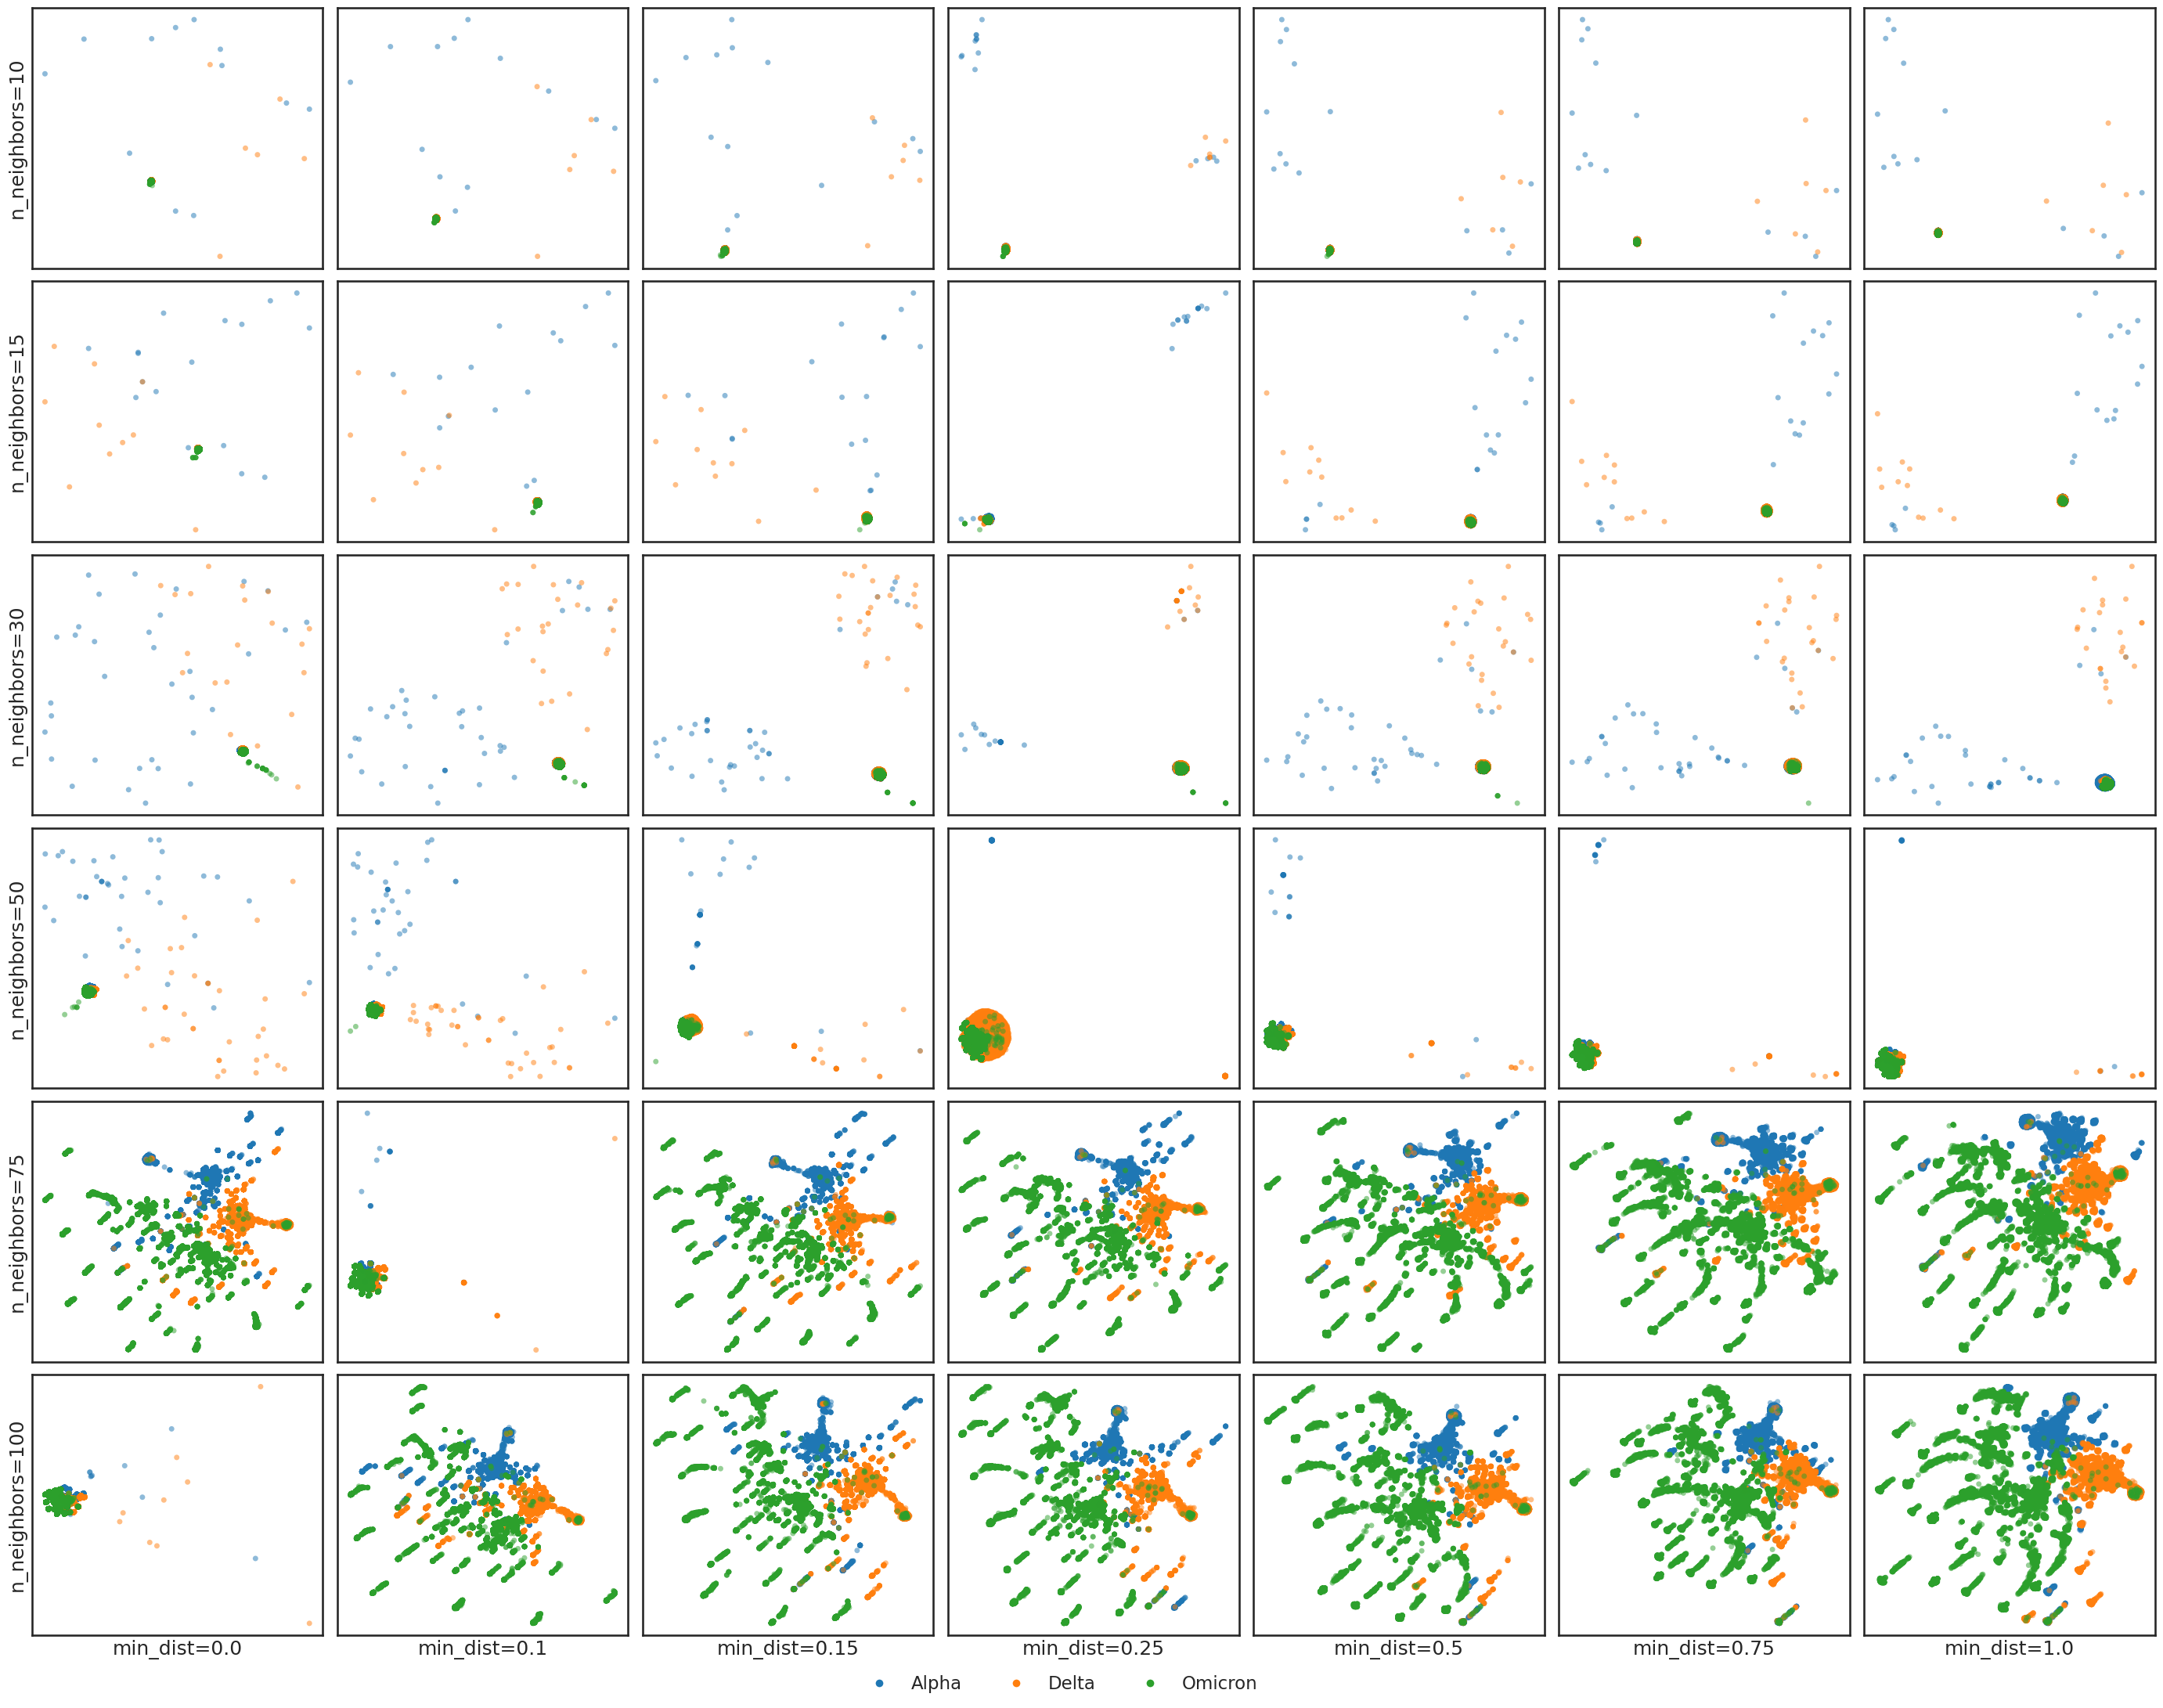

In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_umap_grid(parquet_dir, version_dir, version_prefix, rnd_seed, n_neighbors_list, min_dist_list):
    n_rows = len(n_neighbors_list)
    n_cols = len(min_dist_list)

    sns.set_style("ticks")
    sns.set_context("talk")

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(5 * n_cols, 4.5 * n_rows),
        squeeze=False
    )

    plt.subplots_adjust(hspace=0.05, wspace=0.05)

    for i, n_neighbors in enumerate(n_neighbors_list):
        for j, min_dist in enumerate(min_dist_list):
            ax = axes[i, j]

            parquet_file = os.path.join(parquet_dir, version_dir, f"{version_prefix}.sampled_seed{rnd_seed}.umap-nneighbors{n_neighbors}_mindist{min_dist}.parquet")
            plot_df = pd.read_parquet(parquet_file, engine="fastparquet")

            unique_variants = np.unique(plot_df["Variant"])
            variant_color_palette = sns.color_palette("tab10", n_colors=len(unique_variants))
            variant_color_dict = {
                label: color for label, color in zip(unique_variants, variant_color_palette)
            }
            variant_colors = [variant_color_dict[v] for v in plot_df["Variant"]]

            ax.scatter(
                plot_df["UMAP 1"],
                plot_df["UMAP 2"],
                c=variant_colors,
                s=25,
                alpha=0.5,
                edgecolor="none",
                linewidth=0,
            )

            ax.set_xticks([])
            ax.set_yticks([])

            # Only show y-axis label on first column
            if j == 0:
                ax.set_ylabel(f"n_neighbors={n_neighbors}")

            # Only show x-axis label on bottom row
            if i == n_rows - 1:
                ax.set_xlabel(f"min_dist={min_dist}")

    # One shared legend
    handles = [
        plt.Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor=variant_color_dict[v],
            markersize=8,
        )
        for v in unique_variants
    ]

    fig.legend(
        handles,
        unique_variants,
        loc="lower center",
        ncol=len(unique_variants),
        frameon=False,
        bbox_to_anchor=(0.5, 0.075),
    )

    plt.show()

parquet_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/blackwell/rbd/parquets"
rnd_seed = 0

plot_umap_grid(
    parquet_dir,
    version_dir,
    version_prefix,
    rnd_seed,
    n_neighbors_list=[10, 15, 30, 50, 75, 100],
    min_dist_list=[0.0, 0.1, 0.15, 0.25, 0.5, 0.75, 1.0],
)

In [79]:
import os
import pandas as pd

rnd_seed = 0
sweep_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/blackwell/rbd/param_sweeps"

full_results_umap_df = pd.read_csv(os.path.join(sweep_dir, version_dir, f"{version_prefix}.sampled_seed{rnd_seed}-umap_hdbscan-parameter_sweep.csv"))
scored_results_df = full_results_umap_df.copy()

In [80]:
# Make sure ari between -1 and 1...
invalid_ari_mask = (
    scored_results_df["ari"].notna()
    & ~scored_results_df["ari"].between(-1, 1)
)

print("Invalid ari rows:", invalid_ari_mask.sum())
print("Rows before:", len(scored_results_df))

# Drop invalid rows
scored_results_df = scored_results_df.loc[~invalid_ari_mask].copy()

print("Rows after:", len(scored_results_df))

# Make sure silhouette between -1 and 1...
invalid_silhouette_mask = (
    scored_results_df["silhouette"].notna()
    & ~scored_results_df["silhouette"].between(-1, 1)
)

print("Invalid silhouette rows:", invalid_silhouette_mask.sum())
print("Rows before:", len(scored_results_df))

# Drop invalid rows
scored_results_df = scored_results_df.loc[~invalid_silhouette_mask].copy()

print("Rows after:", len(scored_results_df))

Invalid ari rows: 0
Rows before: 3234
Rows after: 3234
Invalid silhouette rows: 6
Rows before: 3234
Rows after: 3228


### Best result within each UMAP setting, based on just ARI and SC

In [81]:
summary_df = (
    scored_results_df
    .sort_values(by=["ari", "silhouette"], ascending=[False, False])
    .groupby(["n_neighbors", "min_dist"], as_index=False)
    .first()
    .rename(columns={
        "ari": "best_ari",
        "silhouette": "best_silhouette",
        "n_clusters": "best_n_clusters",
        "noise_fraction": "best_noise_fraction",
        "min_samples": "best_min_samples",
        "min_cluster_size": "best_min_cluster_size",
    })
)

print(f"Best overall UMAP + HDBSCAN settings (top 5):")
top5 = (
    summary_df.sort_values(
        by=["best_ari", "best_silhouette"],
        ascending=[False, False]
    ).head(5)
).reset_index(drop=True)
display(top5)

Best overall UMAP + HDBSCAN settings (top 5):


,n_neighbors,min_dist,best_min_samples,best_min_cluster_size,best_ari,best_noise_fraction,best_silhouette,best_n_clusters
0,100,1.00,10,20000,0.855007,0.369573,0.944830,2
1,75,1.00,10,5000,0.848847,0.381321,0.954124,2
2,75,0.75,25,20000,0.839173,0.384432,0.947703,2
3,100,0.75,25,15000,0.838190,0.358143,0.937222,2
4,100,0.25,25,10000,0.811682,0.362718,0.952111,2


Seed 0 | UMAP | n_neighbors = 100, min_dist = 1.0
min_samples = 10, min_cluster_size = 20000: ARI = 0.86, Silhouette = 0.94, Clusters = 2, Noise = 36.96%
2: [0 1]


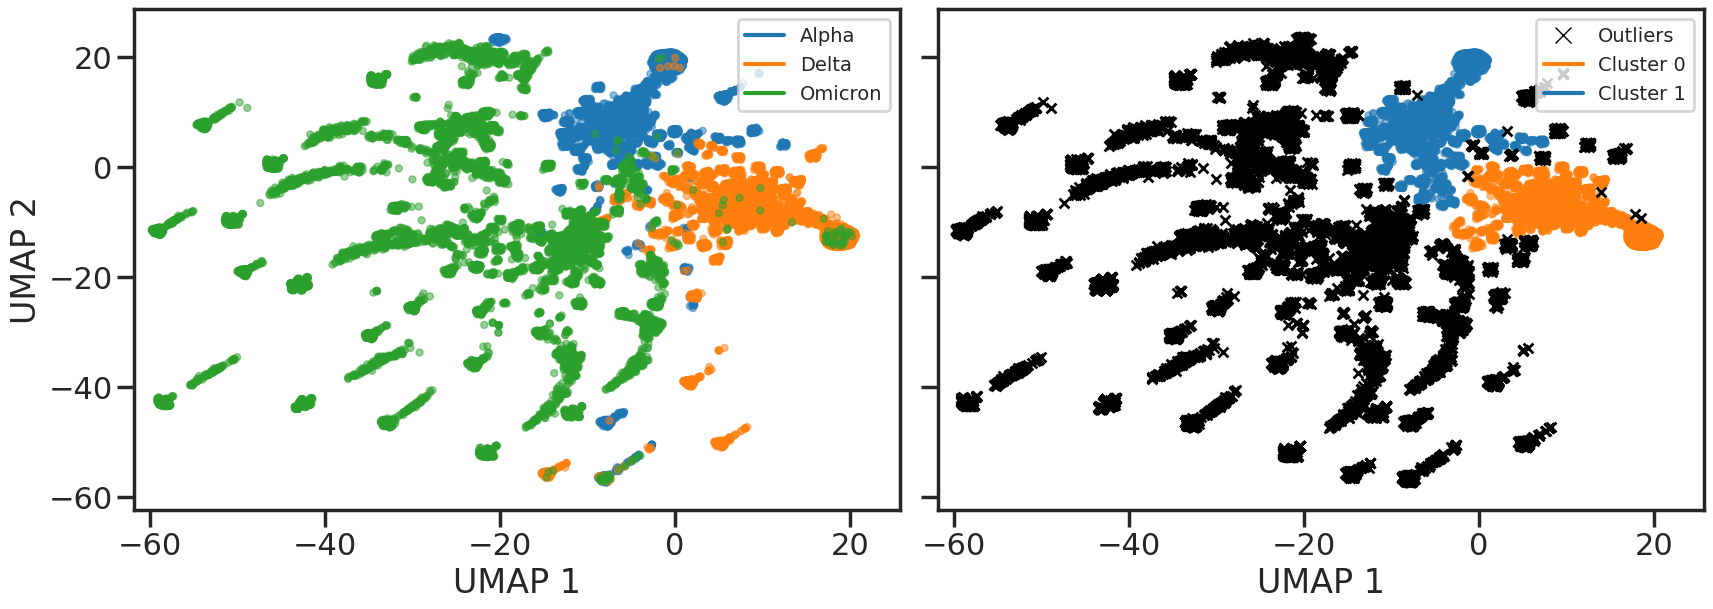

Predicted Clusters,-1,0,1
Ground Truth,,,
Alpha,6.71,0.26,93.03
Delta,5.64,93.51,0.85
Omicron,98.52,0.34,1.13


In [82]:
rnd_seed = 0 # ONLY refers to the data, not the UMAP or TSNE random state

best = top5.iloc[0]
n_neighbors = int(best["n_neighbors"])
min_dist = best["min_dist"]
print(f"Seed 0 | UMAP | n_neighbors = {n_neighbors}, min_dist = {min_dist}")

plot_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/blackwell/rbd/plots"
parquet_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/blackwell/rbd/parquets"
parquet_file = os.path.join(parquet_dir, version_dir, f"{version_prefix}.sampled_seed{rnd_seed}.umap-nneighbors{n_neighbors}_mindist{min_dist}.parquet")

min_samples = int(best["best_min_samples"])
min_cluster_size = int(best["best_min_cluster_size"])
plot_df, truth_table_percent, save_as = get_hdbscan_values(parquet_file, min_samples, min_cluster_size)

unique_clusters = np.unique(plot_df["Cluster"])
non_noise_clusters = unique_clusters[unique_clusters != -1]
print(f"{len(non_noise_clusters)}: {non_noise_clusters}") # use this for cluster_color_palette_order if you want to set it

# Call the function
plot_groundtruth_prediction_1x2(
    plot_df, save_as, 
    plot_dir=os.path.join(plot_dir, version_dir),
    x_min_width_buffer=2, x_max_width_buffer=5, y_min_width_buffer=5, y_max_width_buffer=5, 
    color_map="tab10", 
    cluster_color_palette_order=[1, 0]
)
display(truth_table_percent)

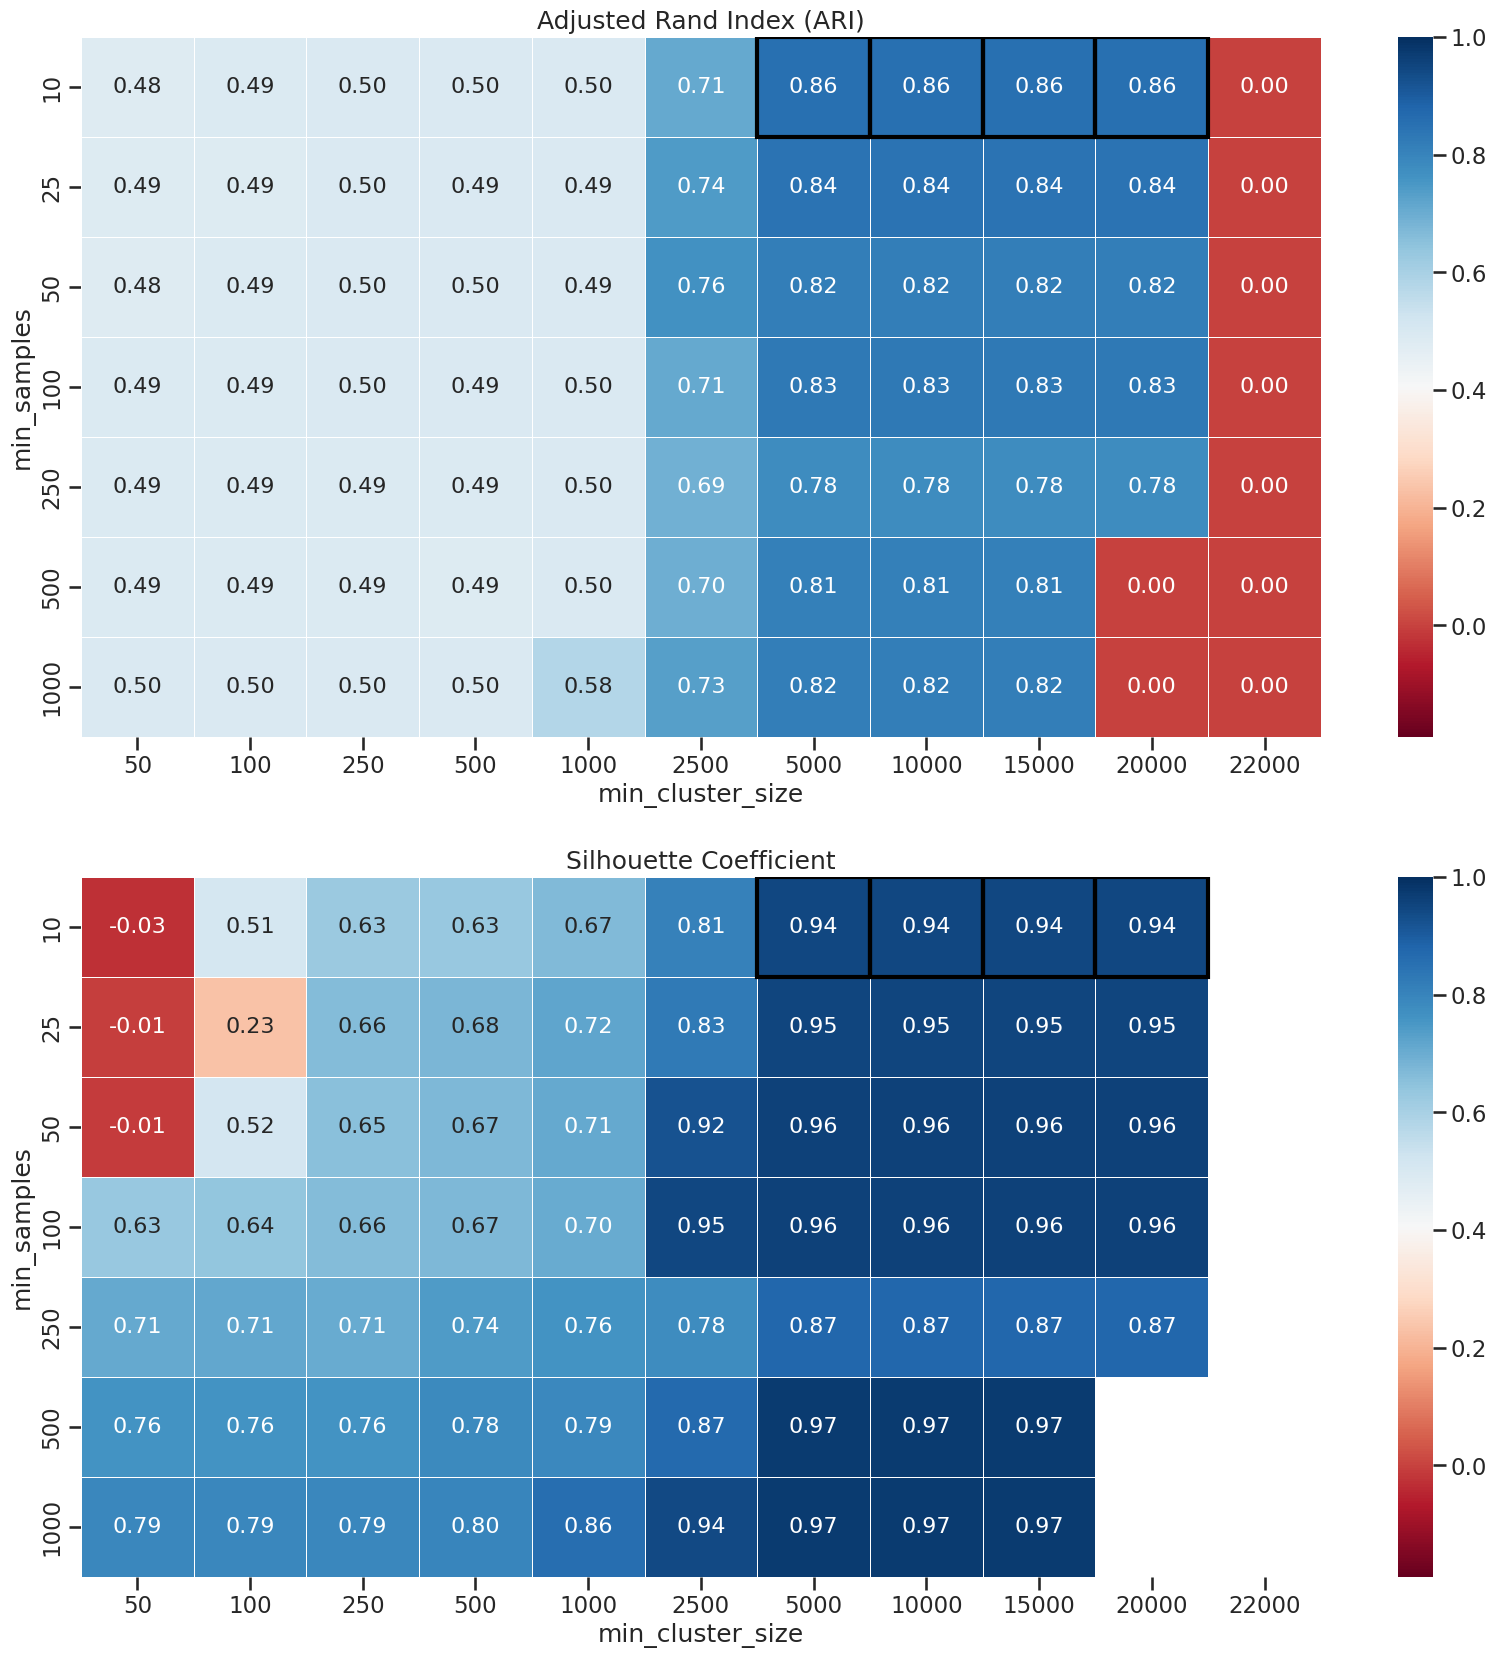

In [83]:
best_df = scored_results_df[
    (scored_results_df["n_neighbors"] == n_neighbors) &
    (scored_results_df["min_dist"] == min_dist)
].copy()

ari_sc_heatmap(
    best_df,
    parquet_file,  
    plot_dir=os.path.join(plot_dir, version_dir),
)

In [84]:
# Cluster info
result = cluster_pango_lineage(plot_df, 5)

clusters = result['Cluster'].unique()
clustered_dataframes = split_dataframe_by_cluster(result)

for cluster in clusters:
    print(f"{clustered_dataframes[cluster]}\n")

   Cluster  Variant Pango lineage  Cluster %  Lineage %
0       -1  Omicron       BA.5.2*   8.551583  99.571836
1       -1  Omicron          BA.2   7.771195  98.041237
2       -1  Omicron       BA.1.1*   7.113381  98.864282
3       -1    Alpha        B.1.1*   5.801839   6.557377
4       -1  Omicron       BQ.1.1*   5.777324  99.088998

   Cluster Variant Pango lineage  Cluster %  Lineage %
0        0   Delta          AY.4  13.346489  95.885201
1        0   Delta      B.1.617*   7.055879  91.339564
2        0   Delta        AY.122   6.396496  92.355803
3        0   Delta        AY.103   5.626414  94.198227
4        0   Delta         AY.43   4.702315  94.396135

   Cluster  Variant Pango lineage  Cluster %  Lineage %
0        1    Alpha        B.1.1*  95.665856  92.652967
1        1    Alpha           Q.3   0.905927  97.435897
2        1    Alpha           Q.4   0.538788  97.413793
3        1    Alpha           Q.1   0.481572  83.471074
4        1  Omicron    Unassigned   0.176417   4.347

In [85]:
cluster_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/blackwell/rbd/clusters"

for cluster in clusters:
    print(cluster)
    cluster_df =  plot_df[plot_df["Cluster"] == cluster]
    print(cluster_df["Variant"].value_counts())

    save_as = f"{version_prefix}.sampled_seed{rnd_seed}.umap-nneighbors{n_neighbors}_mindist{min_dist}.cluster{cluster}"
    cluster_df.to_csv(os.path.join(cluster_dir, version_dir, f"{save_as}.csv"), index=False)

-1
Variant
Omicron    21749
Alpha       1481
Delta       1245
Name: count, dtype: int64
0
Variant
Delta      20643
Omicron       76
Alpha         58
Name: count, dtype: int64
1
Variant
Alpha      20536
Omicron      250
Delta        187
Name: count, dtype: int64


---
### Random Seeds

Matches the n_neighbors and min_dist above:

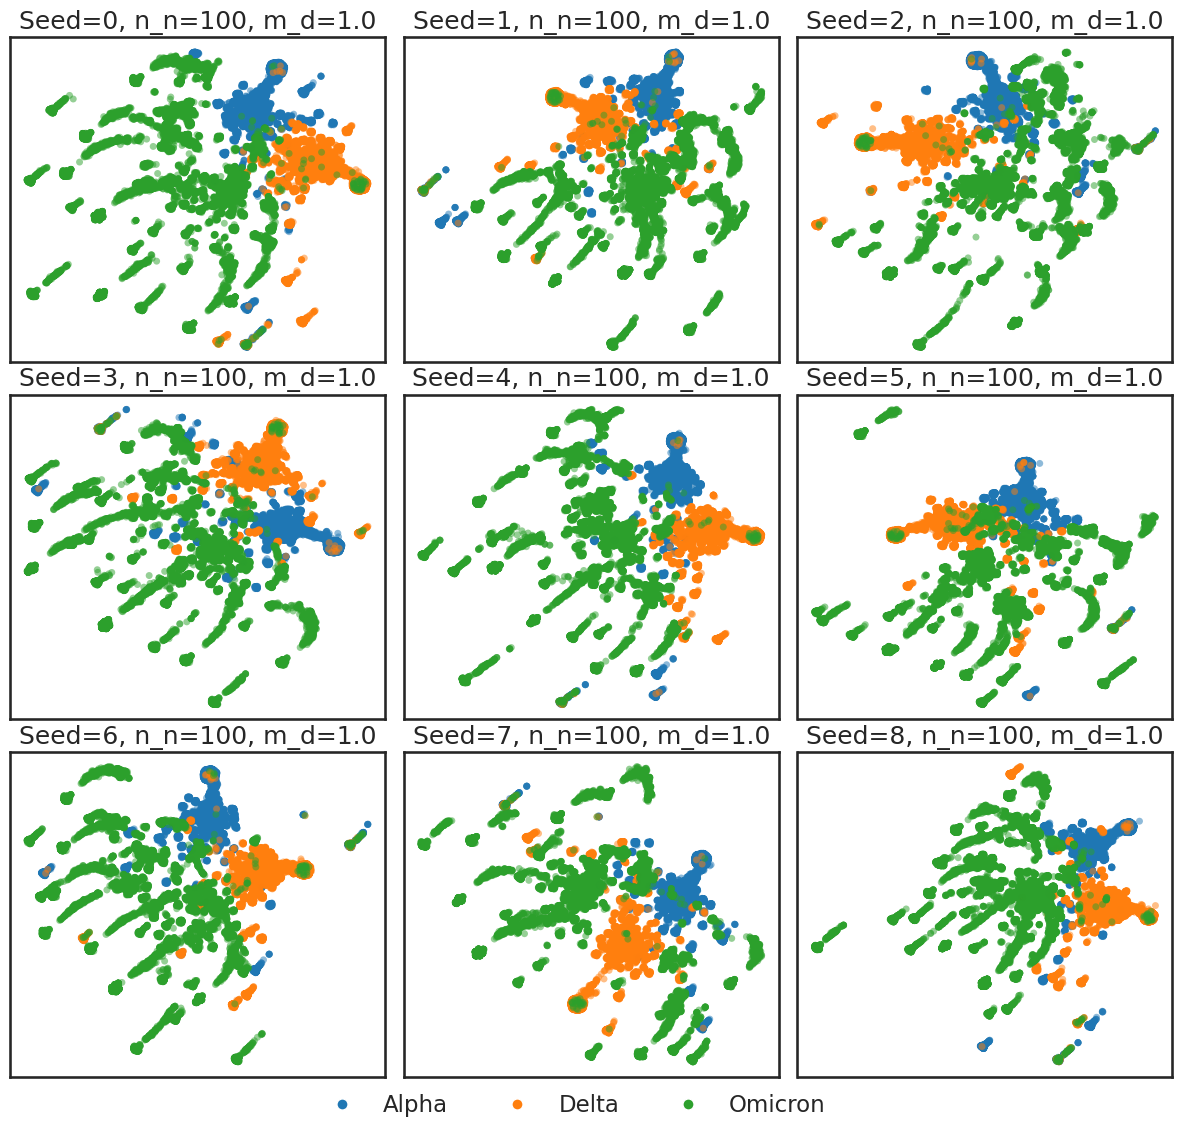

In [87]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_random_seeds(parquet_dir, version_dir, version_prefix, n_neighbors, min_dist, rnd_seed_list):
    n_rows = 3
    n_cols = 3
    
    sns.set_style('ticks')
    sns.set_context("talk")
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(5 * n_cols, 4.5 * n_rows),
        squeeze=False
    )

    plt.subplots_adjust(hspace=0.1, wspace=0.05)

    for ax, seed in zip(axes.flat, rnd_seed_list):
        parquet_file = os.path.join(parquet_dir, version_dir, f"{version_prefix}.sampled_seed{seed}.umap-nneighbors{n_neighbors}_mindist{min_dist}.parquet")
        plot_df = pd.read_parquet(parquet_file, engine='fastparquet')

        unique_variants = np.unique(plot_df['Variant'])
        variant_color_palette = sns.color_palette("tab10", n_colors=len(unique_variants)) 
        variant_color_dict = {label: color for label, color in zip(unique_variants, variant_color_palette)}
        variant_colors = [variant_color_dict[v] for v in plot_df['Variant']]

        ax.scatter(
            plot_df["UMAP 1"],
            plot_df["UMAP 2"],
            c=variant_colors,
            s=25,
            alpha=0.5,
            edgecolor="none",
            linewidth=0,
        )
    
        ax.set_xticks([])
        ax.set_yticks([])

        ax.set_title(f'Seed={seed}, n_n={n_neighbors}, m_d={min_dist}')
        
    for ax in axes.flat[len(rnd_seed_list):]:
        ax.axis("off")

    # One shared legend
    handles = [
        plt.Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor=variant_color_dict[v],
            markersize=8,
        )
        for v in unique_variants
    ]

    fig.legend(
        handles,
        unique_variants,
        loc="lower center",
        ncol=len(unique_variants),
        frameon=False,
        bbox_to_anchor=(0.5, 0.065),
    )

    plt.show()

# Run
parquet_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/blackwell/rbd/parquets"

plot_random_seeds(
    parquet_dir,
    version_dir,
    version_prefix,
    n_neighbors=n_neighbors, 
    min_dist=min_dist,
    rnd_seed_list=[0, 1, 2, 3, 4, 5, 6, 7, 8]
)